In [1]:
%matplotlib inline
# %matplotlib ipympl
%load_ext autoreload
%autoreload 2

import numpy as np

from Utils.load_files import load_binary
from Utils.json_tools import read_formatted_json
# from Utils.recording import detect_exposure_time, interp_replace
from Utils.recording import detect_exposure_time
from Utils.kilosort_utils import gen_adc_spike_time
from pathlib import Path
import matplotlib
# Restart the kernel to revert changes to matplotlib settings
# matplotlib.use('TkAgg')  # Use TkAgg backend for interactive plotting

import matplotlib.pyplot as plt
from Utils.Sessions import Session
from Utils.ttl_utils import fill_short_gaps, gen_delete_by_range_index
from scipy.io import loadmat

from Utils.recording import interp_replace
from Utils.session_edits import check_session_edits



32


In [3]:
"""
Change all the variables below to match recording.
"""

is_overwrite_parameters: bool = True
base_dir = r"/mnt/senzailab/Kai/#Recording/m19"

# base_dir = "data"
date: str | int = "260827"

num_of_rec: int = 10

headplate_name: str = 'hp4'

subfolder_filler = f"{date}_{num_of_rec}"

probe_list: list[str] = ["A", ]

sessionEdit = check_session_edits(
    f"{base_dir}/session_slices.sqlite3",
    date,
    num_of_rec,
)

base_dir = f"{base_dir}/{date}/{subfolder_filler}"

# These are 0 indexed channel numbers
camera_input_channel: int = 1
analogue_input_channel: int = 3

is_convert_to_zero: bool = False
time_interval: bool = False
is_signal_inverted: bool = True

detect_ADC_DI_threshold, fill_short_gaps_1, fill_short_gaps_2 = 15000, 10, 1000
detect_on_list_threshold: float = 0.5

parameters_file = Path(f'{base_dir}/data/parameters.json')

"""------------------------------------------------------------------"""
oebin_file_dir = next((Path(base_dir) / date).glob("*/experiment1/recording1/structure.oebin"))

session = Session(oebin_file_dir)
session_info = session.get_session_info()

base_data_dir = session_info['base_path']
record_nodes: str = session_info['record_nodes']
recording_name: str = session_info['recording_name']
experiment_id: str = session_info['experiment_id']

path_between = f'/{record_nodes}/{experiment_id}/'
continuous_folder = base_data_dir + path_between + recording_name + '/continuous/'
#
# for probe in probe_list:
#     print("==============================")
#     print(f"Generating probe{probe} ADC spike time...")
#     if (_ := gen_adc_spike_time(session_info=session_info,
#                                 probe=probe,
#                                 base_dir=base_dir,
#                                 num_of_rec=num_of_rec,
#                                 save_file_name="adc_spike_time",
#                                 is_convert_to_zero=is_convert_to_zero))[0]:
#         print(f"probe{probe}_continuous_timestamp saved to {_[1]}")

print("==============================")
print("Loading ADC npy data...")
deleteStartIndex = None
deleteEndIndex = None
deleteFrames, interp_start, interp_end, frames_between = None, None, None, None

ADC_name: str = session_info['continuous_ADC_folder']
analogue_total_input_channel_number: int = session_info['ADC_input_channel']
ADC_sampling_rate: float = session_info['ADC_sample_rate']
ADC_datafile = continuous_folder + ADC_name + '/continuous.dat'

photodiode_data = load_binary(ADC_datafile, analogue_total_input_channel_number, analogue_input_channel)

ADC_continuous_time_stamp_file = f'{continuous_folder}/{ADC_name}/timestamps.npy'
ADC_continuous_time_stamp_data_raw = np.load(ADC_continuous_time_stamp_file, mmap_mode='r')

if is_convert_to_zero:
    ADC_continuous_time_stamp_data = (ADC_continuous_time_stamp_data_raw - ADC_continuous_time_stamp_data_raw[0])
else:
    ADC_continuous_time_stamp_data = ADC_continuous_time_stamp_data_raw

assert len(ADC_continuous_time_stamp_data) == len(
    photodiode_data), f"Length mismatch: {len(ADC_continuous_time_stamp_data)} vs {len(photodiode_data)}"

print(f"ADC_continuous_time_stamp_data: {ADC_continuous_time_stamp_data.shape}")
ADC_duration = len(photodiode_data) / ADC_sampling_rate
print(f"ADC duration: {ADC_duration} ")

edge_threshold = 1000
max_internal_gap = 300

raw_active = photodiode_data > edge_threshold

ADC_DI_data_noGap = fill_short_gaps(
    raw_active,
    min_gap=max_internal_gap,
)

# ADC_DI_data_noGap = fill_short_gaps(~(fill_short_gaps(photodiode_data < 15000, min_gap=10)), min_gap=1000)

assert len(ADC_continuous_time_stamp_data) == len(
    ADC_DI_data_noGap), f"Length mismatch: {len(ADC_continuous_time_stamp_data)} vs {len(ADC_DI_data_noGap)}"

on_list_detected = detect_exposure_time(
    ADC_continuous_time_stamp_data,
    ADC_DI_data_noGap,
    threshold=detect_on_list_threshold,
    time_interval=False,
    is_inverted=is_signal_inverted,
    detection_target_label="on_list",
).ravel()

on_list_detected[-1] = (on_list_detected[-1] - 1) if on_list_detected[-1] == len(ADC_continuous_time_stamp_data) else \
    on_list_detected[-1]

on_list_time = ADC_continuous_time_stamp_data[on_list_detected]

"""# 260714_3
# sessionEdit.deleteByFrame([14483, 14484])

# 260716_3
# sessionEdit.deleteByFrame([10120, 10121])

# 260716_4
# sessionEdit.interp(1621, 1623, 13)"""

(saved, stored_data), edited_target = sessionEdit.getSessionInfo(
    target=on_list_time
)

# deleteFrames: list[int] = [16002, 16003]

# deleteStartIndex = 3
# deleteEndIndex = -5

abnormal = []

for index, _ in enumerate(np.diff(on_list_time)):
    if _ < 0.08:
        abnormal.append(index)
    if _ > 0.11:
        abnormal.append(index)

start, end = gen_delete_by_range_index(abnormal, on_list_time)
# (start, end, frames_between)
# interp_start, interp_end, frames_between = 6160, 6163, 12

deleteStartIndex = start
deleteEndIndex = -2
# deleteEndIndex = None

if saved:
    on_list_time = edited_target
    print(f"Stored edits applied: {stored_data}")
else:
    if deleteFrames:
        on_list_time = np.delete(on_list_time, deleteFrames, )

    on_list_time = on_list_time[deleteStartIndex:deleteEndIndex]

    if interp_start:
        on_list_time = interp_replace(
            on_list_time,
            interp_start,
            interp_end,
            new_length=frames_between + 2,
        )

trials = loadmat(f"{base_dir}/{date}.mat")["trials"]

assert len(on_list_time) == len(trials), f"Length mismatch: {len(on_list_time)} vs {len(trials)}"

if not saved:
    print("Saving Data")
    if deleteFrames:
        success, message = sessionEdit.deleteByFrame(deleteFrames)
        if not success:
            print(message)

    if deleteStartIndex:
        success, message = sessionEdit.deleteByRange(deleteStartIndex, deleteEndIndex, )
        if not success:
            print(message)

    if interp_start:
        success, message = sessionEdit.interp(
            interp_start,
            interp_end,
            frames_between,
        )

        if not success:
            print(message)

print("Session edits stored")

# on_list_time = np.append(on_list_time, on_list_time[-1] + 0.1)
on_list_time = np.append(on_list_time[0] - 0.1, on_list_time)

# if num_of_rec == 2:
#     on_list_time = on_list_time[2:]

np.save((npyfile_path := f"{base_dir}/data/on_list_times.npy"), on_list_time)
print(f"on_list_time saved to {npyfile_path}")


Loading session from file: /mnt/senzailab/Kai/#Recording/m19/260827/260827_10/260827/Record Node 102/experiment1/recording1/structure.oebin
Loading ADC npy data...
ADC_continuous_time_stamp_data: (37595900,)
ADC duration: 1240.768304153397 


Processing on_list files: 100%|██████████| 5/5 [100%]


on_list recording start frame (index): 186748
Start index: 5, End index: -3
Stored edits applied: {'date': '260827', 'session_id': '10', 'delete_frames': [0, 1, -2, -1], 'interp_start_end': None, 'interp_frames_between': None}


AssertionError: Length mismatch: 12004 vs 12000

In [5]:
import pandas as pd

on_list = on_list_time[:-1]

camera_data = load_binary(
    ADC_datafile,
    analogue_total_input_channel_number,
    camera_input_channel,
)

low_intervals = detect_exposure_time(
    ADC_continuous_time_stamp_data,
    camera_data,
    threshold=11000,
    time_interval=False,
    is_inverted=False,
    detection_target_label="camera low intervals",
)

low_intervals = low_intervals[
    (low_intervals[:, 0] > 0) &
    (low_intervals[:, 1] < len(camera_data))
    ]
frame_times = (ADC_continuous_time_stamp_data[low_intervals[:, 0]] + ADC_continuous_time_stamp_data[low_intervals[:, 1]]) / 2

hd_content = read_formatted_json(
    f"{base_dir}/data/processed/head_direction.json"
)
calib = read_formatted_json(next(Path(base_dir).glob("*.calib")))

raw_hd = np.asarray(
    hd_content[headplate_name]["head_direction_deg"],
    dtype=float,
)

motive = pd.read_csv(
    f"{base_dir}/{date}.csv", header=[2, 3, 6, 7], skip_blank_lines=False,
)
if len(motive) != len(raw_hd):
    raise ValueError(f"CSV/HD frame count mismatch: {len(motive)} vs {len(raw_hd)}")

if len(raw_hd) == len(frame_times) + 1:
    hd = raw_hd[:-1]
    motive = motive.iloc[:-1].copy()
    print("Dropped the last CSV and HD frame to match camera frame times.")
elif len(raw_hd) == len(frame_times) + 2:
    hd = raw_hd[1:-1]
    motive = motive.iloc[1:-1].copy()
    print("Dropped the first and last CSV/HD frames to match camera frame times.")
elif len(raw_hd) != len(frame_times):
    # raise ValueError(f"HD/camera frame count mismatch: {len(raw_hd)} vs {len(frame_times)}")
    hd = raw_hd[:len(frame_times)]
    motive = motive.iloc[:len(frame_times)].copy()
else:
    hd = raw_hd

hd = (hd - calib["screen_center"]) % 360

hd_unwrapped = np.unwrap(np.radians(hd))
selected_hd = np.degrees(
    np.interp(on_list, frame_times, hd_unwrapped)
) % 360

selected_hd_pix = selected_hd / 360 * 960

np.save(
    f"{base_dir}/data/hd_trials_times.npy",
    selected_hd_pix,
)


eye_offset = np.asarray(calib["hp_to_eye_center"][:2], dtype=float)
screen_center = np.asarray(calib["screen_bottom_center"][:2], dtype=float)

position_xy = (
    motive["Rigid Body"][headplate_name]["Position"][["X", "Y"]]
    .to_numpy(dtype=float, copy=True)
)

theta = np.radians(hd)

eye_offset_world = np.column_stack([
    eye_offset[0] * np.cos(theta) - eye_offset[1] * np.sin(theta),
    eye_offset[0] * np.sin(theta) + eye_offset[1] * np.cos(theta),
])

eye_xy = position_xy + eye_offset_world
eye_xy -= screen_center

# Interpolate on the ADC clock; one [x, y] row per trial onset, in CSV units.
position_trials_time = np.column_stack([
    np.interp(on_list, frame_times, eye_xy[:, axis],
              left=np.nan, right=np.nan)
    for axis in range(2)
])
assert position_trials_time.shape == (len(trials), 2)

np.save((npyfile_path := f"{base_dir}/data/position_trials_time.npy"), position_trials_time)
print(f"position_trials_time {position_trials_time.shape} saved to {npyfile_path}")


Processing camera low intervals files: 100%|██████████| 5/5 [100%]


camera low intervals recording start frame (index): 0
Dropped the last CSV and HD frame to match camera frame times.
position_trials_time (12000, 2) saved to /mnt/senzailab/Kai/#Recording/m19/260821/260821_6/data/position_trials_time.npy


In [ ]:
print("first 10:", on_list_time[:10], "\n")

print("last 10:", on_list_time[-10:])

In [ ]:
for index, _ in enumerate(np.diff(on_list_time)):
    if _ < 0.08:
        print("Too short:")
        print(f"Gap detected at index {index}: {on_list_time[index]} to {on_list_time[index + 1]} (gap: {_})")
    if _ > 0.18:
        print("Too long:")
        print(f"Gap detected at index {index}: {on_list_time[index]} to {on_list_time[index + 1]} (gap: {_})")

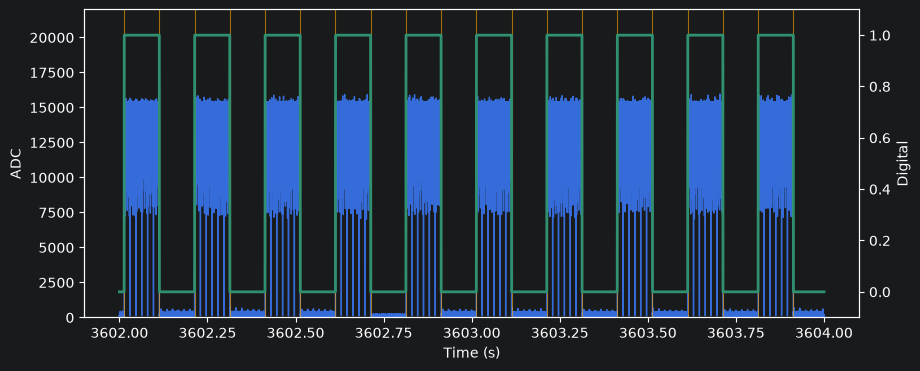

array([919575, 922601, 925634, 928661, 931694, 934720, 937753, 940780,
       943813, 946839, 949872, 952899, 955932, 958958, 961991, 965018,
       968051, 971077, 974110, 977137])

In [8]:
start_time, end_time = 3602, 3604
# start_time, end_time = (on_list_time[0] - 2), (on_list_time[2] + 1)  # Start
# start_time, end_time = (on_list_time[-2] - 2), (on_list_time[-1] + 1)  # End

# start_time, end_time = 55, 58


start_idx = np.searchsorted(ADC_continuous_time_stamp_data, start_time, side="left")
end_idx = np.searchsorted(ADC_continuous_time_stamp_data, end_time, side="right")

x = ADC_continuous_time_stamp_data[start_idx:end_idx]
y1 = photodiode_data[start_idx:end_idx]
y2 = ADC_DI_data_noGap[start_idx:end_idx]
edges_list = on_list_time

fig, ax1 = plt.subplots(figsize=(10, 4))

l1 = ax1.plot(x, y1, color='C0', lw=1, label='ADC')
ax1.set_ylim(0, 22000)
ax1.set_xlabel("Time (s)")
ax1.set_ylabel("ADC")

ax2 = ax1.twinx()
l2 = ax2.plot(x, y2, color='C3', lw=2, label='Digital')
ax2.set_ylim(-0.1, 1.1)
ax2.set_ylabel("Digital")

# Add on_list rising/falling edge markers inside this displayed time window.
# on_list_time is already in the same time base as x.
left = np.searchsorted(edges_list, x[0], side="left")
right = np.searchsorted(edges_list, x[-1], side="right")
visible_edges = edges_list[left:right]

visible_edge_indices = np.searchsorted(ADC_continuous_time_stamp_data, visible_edges)

for t in visible_edges:
    ax1.axvline(t, color="orange", lw=0.8, alpha=0.6)
plt.show()

visible_edge_indices

In [ ]:
print(on_list_detected[6163:6169])

In [ ]:
np.save((npyfile_path := f"{base_dir}/data/on_list_times.npy"), on_list_idx_patched)


np.float64(1240.6716237906767)

In [ ]:
a = on_list_time[1621]  # 47724427
b = on_list_time[1623]  # 47788633
n_insert = 14

normal_dt = np.median(np.diff(on_list_time))
n_interval = round((b - a) / normal_dt)
n_insert = n_interval - 1

inserted_t = np.linspace(a, b, n_insert + 2)[1:-1]

on_list_idx_patched = np.insert(on_list_time, 1622, inserted_t)

In [ ]:
base_dir = Path(base_dir)

continuous_dir = Path(continuous_folder)
recording_dir = continuous_dir.parent
events_dir = recording_dir / "events"

adc_stream = ADC_name.rstrip("/")

ADC_continuous_time_stamp_file = f'{continuous_folder}/{ADC_name}/timestamps.npy'
ADC_continuous_time_stamp_data_raw = np.load(ADC_continuous_time_stamp_file, mmap_mode='r')
ADC_continuous_time_stamp_data = ADC_continuous_time_stamp_data_raw  # - ADC_continuous_time_stamp_data_raw[0]
ADC_event_timestamp_raw = np.load(events_dir / adc_stream / "TTL" / "timestamps.npy", mmap_mode="r")
ADC_event_timestamp = ADC_event_timestamp_raw  # - ADC_continuous_time_stamp_data_raw[0]
if len(ADC_event_timestamp) < 2 or not np.all(np.diff(ADC_event_timestamp) > 0):
    raise ValueError("ADC TTL timestamps must contain at least two strictly increasing values.")

for probe in probe_list:
    probe = probe.upper()
    probe_stream = session_info[f"continuous_probe_{probe}_folder"].rstrip("/")

    probe_continuous_time_stamp_file = f'{continuous_folder}{probe_stream}/timestamps.npy'
    probe_continuous_time_stamp_data_raw = np.load(probe_continuous_time_stamp_file, mmap_mode='r')
    probe_continuous_time_stamp_data = probe_continuous_time_stamp_data_raw  # - probe_continuous_time_stamp_data_raw[0]

    probe_event_timestamp_raw = np.load(events_dir / probe_stream / "TTL" / "timestamps.npy", mmap_mode="r")
    probe_event_timestamp = probe_event_timestamp_raw  #- probe_continuous_time_stamp_data_raw[0]

    assert len(probe_event_timestamp) == len(ADC_event_timestamp), (
        f"Probe{probe} and ADC TTL counts differ: "
        f"{len(probe_event_timestamp)} vs {len(ADC_event_timestamp)}"
    )

    # probe_before_first_event = probe_continuous_time_stamp_data < probe_event_timestamp[0]
    # probe_after_last_event = probe_continuous_time_stamp_data > probe_event_timestamp[-1]
    # probe_spike_time = probe_continuous_time_stamp_data

    adc_probe_continuous_time_stamp_data = np.interp(
        probe_continuous_time_stamp_data,
        probe_event_timestamp,
        ADC_event_timestamp,
        left=0.0,
        right=float(ADC_continuous_time_stamp_data[-1]),
    )

    upscaled_adc_probe_continuous_time_stamp_data = np.interp(
        np.linspace(0,
                    len(adc_probe_continuous_time_stamp_data) - 1,
                    len(ADC_continuous_time_stamp_data), ),
        np.arange(len(adc_probe_continuous_time_stamp_data)),
        adc_probe_continuous_time_stamp_data,
    )

"""    probe_spike_time_all = np.load(f"{base_dir}/data/probe{probe}/probe_spike_time.npy")
    spike_before_first_event = probe_spike_time_all < probe_event_timestamp[0]
    spike_after_last_event = probe_spike_time_all > probe_event_timestamp[-1]
    probe_spike_time = probe_spike_time_all
    adc_spike_time = np.interp(
        probe_spike_time,
        probe_event_timestamp,
        ADC_event_timestamp,
        left=0.0,
        right=float(ADC_continuous_time_stamp_data[-1]),
    )

    assert len(adc_spike_time) == len(probe_spike_time)

    np.save(f"{base_dir}/data/probe{probe}/adc_spike_time.npy", adc_spike_time)
    print(
        f"Probe{probe}: kept all {len(adc_spike_time)} spikes; "
        f"set {spike_before_first_event.sum()} before the first TTL to 0 and "
        f"{spike_after_last_event.sum()} after the last TTL to the ADC continuous endpoint."
    )"""



In [ ]:
"""
Change all the variables below to match recording.
"""

is_overwrite_parameters: bool = True
base_dir = r"/mnt/senzailab/Kai/#Recording/m15"

# base_dir = "data"
date: str | int = "260706"

base_dir = f"{base_dir}/{date}"

# These are 0 indexed channel numbers
analogue_input_channel: int = 11

# Index of adc
recording_start_index: int = 0
recording_end_index: int = -1

time_interval: bool = False
is_signal_inverted: bool = True

detect_ADC_DI_threshold, fill_short_gaps_1, fill_short_gaps_2 = 15000, 10, 1000
detect_on_list_threshold: float = 0.5

parameters_file = Path(f'{base_dir}/data/parameters.json')

"""------------------------------------------------------------------"""

oebin_file_dir = next((Path(base_dir) / date).glob("*/experiment1/recording1/structure.oebin"))

session = Session(oebin_file_dir)
session_info = session.get_session_info()

base_data_dir = session_info['base_path']
record_nodes: str = session_info['record_nodes']
recording_name: str = session_info['recording_name']
experiment_id: str = session_info['experiment_id']

path_between = f'/{record_nodes}/{experiment_id}/'
continuous_folder = base_data_dir + path_between + recording_name + '/continuous/'

print("==============================")
print("Loading ADC npy data...")
ADC_name: str = session_info['continuous_ADC_folder']
analogue_total_input_channel_number: int = session_info['ADC_input_channel']
ADC_sampling_rate: float = session_info['ADC_sample_rate']
ADC_datafile = continuous_folder + ADC_name + '/continuous.dat'

photodiode_data = load_binary(ADC_datafile, analogue_total_input_channel_number, analogue_input_channel)[
    recording_start_index:recording_end_index]

ADC_continuous_time_stamp_file = f'{continuous_folder}/{ADC_name}/timestamps.npy'
ADC_continuous_time_stamp_data = ((ADC_continuous_time_stamp_data_raw := np.load(
    ADC_continuous_time_stamp_file, mmap_mode='r')) - ADC_continuous_time_stamp_data_raw[0])[
    recording_start_index:recording_end_index]

assert len(ADC_continuous_time_stamp_data) == len(
    photodiode_data), f"Length mismatch: {len(ADC_continuous_time_stamp_data)} vs {len(photodiode_data)}"

print(f"ADC_continuous_time_stamp_data: {ADC_continuous_time_stamp_data.shape}")
ADC_duration = len(photodiode_data) / ADC_sampling_rate
print(f"ADC duration: {ADC_duration} ")

ADC_DI_data_noGap = fill_short_gaps(~(fill_short_gaps(photodiode_data < 15000, min_gap=10)), min_gap=1000)

assert len(ADC_continuous_time_stamp_data) == len(
    ADC_DI_data_noGap), f"Length mismatch: {len(ADC_continuous_time_stamp_data)} vs {len(ADC_DI_data_noGap)}"

on_list_detected = detect_exposure_time(
    ADC_continuous_time_stamp_data,
    ADC_DI_data_noGap,
    threshold=detect_on_list_threshold,
    time_interval=False,
    is_inverted=is_signal_inverted,
    detection_target_label="on_list",
).ravel()

on_list_detected[-1] = (on_list_detected[-1] - 1) if on_list_detected[-1] == len(ADC_continuous_time_stamp_data) else \
    on_list_detected[-1]

on_list_time = ADC_continuous_time_stamp_data[on_list_detected]

#--------------
# manual  correction
# on_list_time = on_list_time[:-2]


np.save((npyfile_path := f"{base_dir}/data/on_list_times11.npy"), on_list_time)
print(f"on_list_time saved to {npyfile_path}")

In [ ]:
vs = np.load(f"{base_dir}/data/on_list_times11.npy")[1:]
photodiode = np.load(f"{base_dir}/data/on_list_times.npy")

In [ ]:
1000 * (vs - 11)[4:]

In [ ]:
1000 * (photodiode - 11)[4:]